This code uses feature based learning to annotate fight bouts

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve
import cv2
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from matplotlib import pyplot as plt
from matplotlib import animation
from matplotlib import rcParams
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score, roc_auc_score, precision_score, recall_score, accuracy_score
)
from sklearn.model_selection import train_test_split
import warnings
from collections import deque
from sklearn.linear_model import LinearRegression

Features with labels

In [93]:
#generates csv with features for learning model

csv_path = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_TL_20250704/idtracker/session_ABpatternvsABpattern_trimmed_cropped/trajectories/trajectories_csv/trajectories.csv"
fps = 60

data = pd.read_csv(csv_path)
fish1 = data.iloc[:, [1, 2]].values
fish2 = data.iloc[:, [3, 4]].values

fish1 = np.nan_to_num(fish1, nan=0.0)
fish2 = np.nan_to_num(fish2, nan=0.0)

# ---- FEATURES ----

# iad
distance = np.linalg.norm(fish1 - fish2, axis=1)

# speed 
speed1 = np.linalg.norm(np.diff(fish1, axis=0, prepend=fish1[0:1]), axis=1) * fps
speed2 = np.linalg.norm(np.diff(fish2, axis=0, prepend=fish2[0:1]), axis=1) * fps

# acceleration
acc1 = np.diff(speed1, prepend=speed1[0]) * fps
acc2 = np.diff(speed2, prepend=speed2[0]) * fps

# heading
dx1 = np.diff(fish1[:,0], prepend=fish1[0,0])
dy1 = np.diff(fish1[:,1], prepend=fish1[0,1])
heading1 = np.arctan2(dy1, dx1)

dx2 = np.diff(fish2[:,0], prepend=fish2[0,0])
dy2 = np.diff(fish2[:,1], prepend=fish2[0,1])
heading2 = np.arctan2(dy2, dx2)

# relative heading
rel_heading_1tow2 = (heading2 - heading1 + np.pi) % (2*np.pi) - np.pi
rel_heading_2tow1 = (heading1 - heading2 + np.pi) % (2*np.pi) - np.pi

# ---- FIGHT LABELS ----

# simple detection using your rule-based function
def detect_fights(distance, speed1, speed2, window=20, min_bout_len=1):
    fight_frames = []
    for i in range(window, len(distance)):
        d_diff = distance[i - window] - distance[i]
        s1_now = speed1[i]
        s2_now = speed2[i]
        s1_diff = s1_now - speed1[i - window]
        s2_diff = s2_now - speed2[i - window]
        if (
            d_diff > 5 and
            (s1_diff > 5 or s2_diff > 5)
        ):
            fight_frames.append(i)
    bouts = []
    if not fight_frames:
        return bouts
    start = fight_frames[0]
    prev = fight_frames[0]
    for f in fight_frames[1:]:
        if f - prev > 1:
            if prev - start + 1 >= min_bout_len:
                bouts.append((start, prev))
            start = f
        prev = f
    if prev - start + 1 >= min_bout_len:
        bouts.append((start, prev))
    return bouts

fight_bouts = detect_fights(distance, speed1, speed2)

# frame-level fight labels
fight_labels = np.zeros(len(distance), dtype=int)
for start, end in fight_bouts:
    fight_labels[start:end+1] = 1

# ---- FINAL DATAFRAME ----

df = pd.DataFrame({
    'frame': np.arange(len(distance)),
    'x1': fish1[:,0],
    'y1': fish1[:,1],
    'x2': fish2[:,0],
    'y2': fish2[:,1],
    'inter_animal_distance': distance,
    'speed1': speed1,
    'speed2': speed2,
    'acc1': acc1,
    'acc2': acc2,
    'heading1': heading1,
    'heading2': heading2,
    'relative_heading_1tow2': rel_heading_1tow2,
    'relative_heading_2tow1': rel_heading_2tow1,
    'fight_label': fight_labels
})

# Save to a new path of your choice
output_csv_path = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_TL_20250704/analysis/features_with_labels_1.csv"
df.to_csv(output_csv_path, index=False)
print("Saved features_with_labels.csv successfully!")


Saved features_with_labels.csv successfully!


   frame       x1       y1       x2       y2  inter_animal_distance  \
0      0  294.975  294.550  288.229  342.793              48.712376   
1      1  294.201  295.313  287.532  342.781              47.934190   
2      2  293.554  295.968  285.832  343.074              47.734731   
3      3  292.274  297.072  284.572  343.100              46.667950   
4      4  291.044  298.348  283.711  343.336              45.581718   

       speed1      speed2         acc1         acc2  heading1  heading2  \
0    0.000000    0.000000     0.000000     0.000000  0.000000  0.000000   
1   65.211057   41.826198  3912.663441  2509.571852  2.363351 -3.124378   
2   55.240224  103.503896  -598.249972  3700.661883  2.350050  2.970917   
3  101.419809   75.616094  2770.775054 -1673.268123  2.429886  3.120961   
4  106.338486   53.565485   295.120636 -1323.036502  2.337841  2.874063   

   relative_heading_1tow2  relative_heading_2tow1  fight_label  
0                0.000000                0.000000        

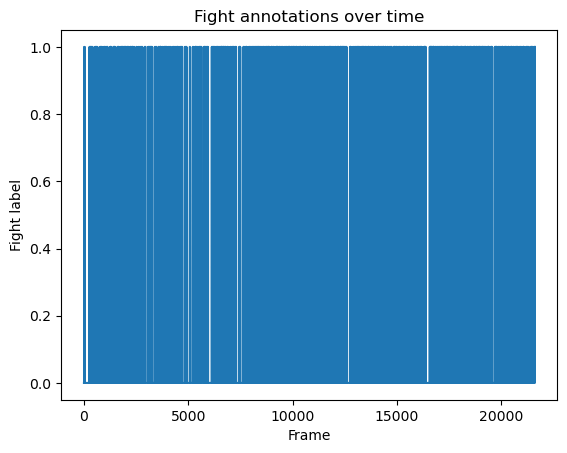

In [94]:
#load csv
df = pd.read_csv("/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_TL_20250704/analysis/features_with_labels_1.csv")

print(df.head())
print(df['fight_label'].value_counts())  # check class balance

# optional quick plot:
plt.plot(df['frame'], df['fight_label'])
plt.xlabel("Frame")
plt.ylabel("Fight label")
plt.title("Fight annotations over time")
plt.show()

Prepare training data by creating temporal aspect using sliding windows

In [95]:
def extract_temporal_features(window_df: pd.DataFrame) -> dict:
    features = {}
    window_size = len(window_df)
    t = np.arange(window_size).reshape(-1, 1)

    for col in window_df.columns:
        x = window_df[col].values
        if np.isnan(x).any():
            features[f"{col}_slope"] = np.nan
            features[f"{col}_delta"] = np.nan
            features[f"{col}_mean"] = np.nan
            features[f"{col}_std"] = np.nan
            features[f"{col}_max"] = np.nan
            features[f"{col}_min"] = np.nan
            continue
        model = LinearRegression().fit(t, x)
        features[f"{col}_slope"] = model.coef_[0]
        features[f"{col}_delta"] = x[-1] - x[0]
        features[f"{col}_mean"] = np.mean(x)
        features[f"{col}_std"] = np.std(x)
        features[f"{col}_max"] = np.max(x)
        features[f"{col}_min"] = np.min(x)

    # Chase flag
    dist_slope = features.get("inter_animal_distance_slope", 0)
    speed1_max = features.get("speed1_max", 0)
    features["chase_flag"] = int((dist_slope < -0.1) and (speed1_max > 10))

    # Burst detection
    if "speed1" in window_df.columns and not window_df["speed1"].isna().any():
        speed = window_df["speed1"].values
        speed_diff = np.diff(speed)
        features["speed1_burst_magnitude"] = np.max(speed_diff)
        features["speed1_burst_frame"] = np.argmax(speed_diff)
    else:
        features["speed1_burst_magnitude"] = np.nan
        features["speed1_burst_frame"] = -1

    # Close-then-burst logic
    if "inter_animal_distance" in window_df.columns and not window_df["inter_animal_distance"].isna().any():
        iad = window_df["inter_animal_distance"].values
        iad_min = np.min(iad)
        iad_min_frame = np.argmin(iad)
        burst_frame = features.get("speed1_burst_frame", -1)
        burst_magnitude = features.get("speed1_burst_magnitude", 0)
        burst_offset = burst_frame - iad_min_frame
        features["inter_animal_distance_min"] = iad_min
        features["inter_animal_distance_min_frame"] = iad_min_frame
        features["burst_after_contact_frames"] = burst_offset
        features["close_then_burst"] = int((iad_min < 5) and (burst_offset >= 1) and (burst_magnitude > 10))
    else:
        features["close_then_burst"] = 0
        features["burst_after_contact_frames"] = -99

    # Aggressor/defender inference
    try:
        x1 = window_df["x1"].values
        y1 = window_df["y1"].values
        x2 = window_df["x2"].values
        y2 = window_df["y2"].values

        if any(np.isnan(v).any() for v in [x1, y1, x2, y2]):
            raise ValueError("NaNs in position data")

        v1 = np.array([x1[-1] - x1[0], y1[-1] - y1[0]])
        v2 = np.array([x2[-1] - x2[0], y2[-1] - y2[0]])
        r12 = np.array([x2[-1] - x1[-1], y2[-1] - y1[-1]])
        r21 = -r12

        def safe_norm(v): return np.linalg.norm(v) + 1e-6
        cos1 = np.dot(v1, r12) / (safe_norm(v1) * safe_norm(r12))
        cos2 = np.dot(v2, r21) / (safe_norm(v2) * safe_norm(r21))

        if cos1 > cos2:
            features["aggressor_id"] = 1
            features["defender_id"] = 2
            approach_vec = r12
            aggressor_heading = window_df["heading1"].values[-1]
        else:
            features["aggressor_id"] = 2
            features["defender_id"] = 1
            approach_vec = r21
            aggressor_heading = window_df["heading2"].values[-1]

        heading_rad = np.deg2rad(aggressor_heading)
        heading_vec = np.array([np.cos(heading_rad), np.sin(heading_rad)])
        approach_vec /= safe_norm(approach_vec)
        dot = np.clip(np.dot(heading_vec, approach_vec), -1, 1)
        angle = np.arccos(dot)
        features["approach_angle_diff_deg"] = np.rad2deg(angle)

    except Exception:
        features["aggressor_id"] = -1
        features["defender_id"] = -1
        features["approach_angle_diff_deg"] = np.nan

    return features

def generate_temporal_features_from_csv(
    csv_path,
    feature_columns,
    label_column="fight_label",
    frame_column="frame",
    window_size=40,
):
    df = pd.read_csv(csv_path)

    # Drop rows with missing feature or label data
    df = df.dropna(subset=feature_columns + [label_column, frame_column])

    feature_rows = []
    for i in range(window_size - 1, len(df)):
        window_df = df.iloc[i - window_size + 1 : i + 1][feature_columns]

        # Skip if window contains any NaNs
        if len(window_df) != window_size or window_df.isna().any().any():
            continue

        try:
            temporal_features = extract_temporal_features(window_df)
            temporal_features["frame"] = df[frame_column].iloc[i]
            temporal_features["label"] = df[label_column].iloc[i]
            feature_rows.append(temporal_features)
        except Exception as e:
            print(f"Skipping frame {df[frame_column].iloc[i]} due to error: {e}")

    X_y_df = pd.DataFrame(feature_rows)
    return X_y_df

# --- CONFIGURATION ---
csv_path = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_TL_20250704/analysis/features_with_labels_1.csv"
feature_columns = [
    'inter_animal_distance',
    'speed1', 'speed2',
    'acc1', 'acc2',
    'heading1', 'heading2',
    'relative_heading_1tow2', 'relative_heading_2tow1',
    'x1', 'y1', 'x2', 'y2'
]

X_y_df = generate_temporal_features_from_csv(
    csv_path=csv_path,
    feature_columns=feature_columns,
    label_column="fight_label",
    frame_column="frame",
    window_size=40
)

# --- SAVE OUTPUT ---
save_path = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_TL_20250704/analysis/rf_temporal_windowed_features_1.csv"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
X_y_df.to_csv(save_path, index=False)
print(f"Saved {len(X_y_df)} rows to: {save_path}")

Saved 21561 rows to: /Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_TL_20250704/analysis/rf_temporal_windowed_features_1.csv


Train the model

Raw predictions:
[[3414   54]
 [  76  768]]
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      3468
         1.0       0.93      0.91      0.92       844

    accuracy                           0.97      4312
   macro avg       0.96      0.95      0.95      4312
weighted avg       0.97      0.97      0.97      4312


Threshold-adjusted predictions (threshold=0.4):
[[3395   73]
 [  55  789]]
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      3468
         1.0       0.92      0.93      0.92       844

    accuracy                           0.97      4312
   macro avg       0.95      0.96      0.95      4312
weighted avg       0.97      0.97      0.97      4312



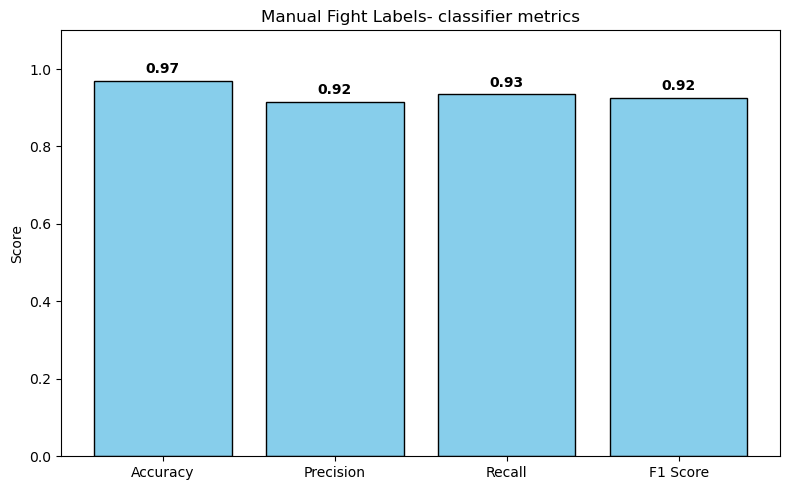

In [81]:
df_windowed = pd.read_csv("/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_pattern_vs_nopattern/analysis/rf_temporal_windowed_features_1_rot.csv")

X = df_windowed.drop(columns=["label", "frame"])
y = df_windowed["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(class_weight="balanced", random_state=42)
clf.fit(X_train, y_train)

# Raw predictions
y_pred = clf.predict(X_test)
print("Raw predictions:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Thresholded predictions using probabilities
y_probs = clf.predict_proba(X_test)[:, 1]
threshold = 0.4
y_pred_adjusted = (y_probs >= threshold).astype(int)

# Compute metrics
accuracy = accuracy_score(y_test, y_pred_adjusted)
precision = precision_score(y_test, y_pred_adjusted)
recall = recall_score(y_test, y_pred_adjusted)
f1 = f1_score(y_test, y_pred_adjusted)

# Print report
print(f"\nThreshold-adjusted predictions (threshold={threshold}):")
print(confusion_matrix(y_test, y_pred_adjusted))
print(classification_report(y_test, y_pred_adjusted))

# Save model
joblib.dump((clf, X_train.columns.tolist()), "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/ML_model/clf_v1_t1.pkl")

# --- Bar Plot ---
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

labels = list(metrics.keys())
values = list(metrics.values())

plt.figure(figsize=(8, 5))
plt.bar(labels, values, color="skyblue", edgecolor="black")
plt.ylim(0, 1.1)  # <-- Increase y-axis limit to allow room for text
plt.ylabel("Score")
plt.title("Manual Fight Labels- classifier metrics")

# Adjust text position to stay inside visible plot
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight='bold')

plt.tight_layout()
plt.savefig("/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_pattern_vs_nopattern/analysis/fight_label_barplot_i3.png")
plt.show()


Threshold plotting

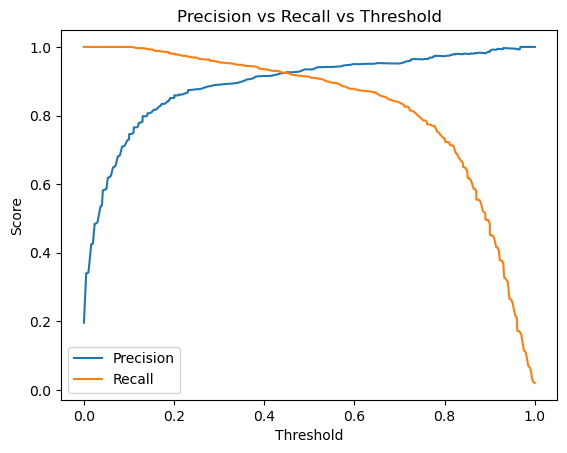

In [80]:
#plot to find thresholds

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()
plt.show()


Feature importance

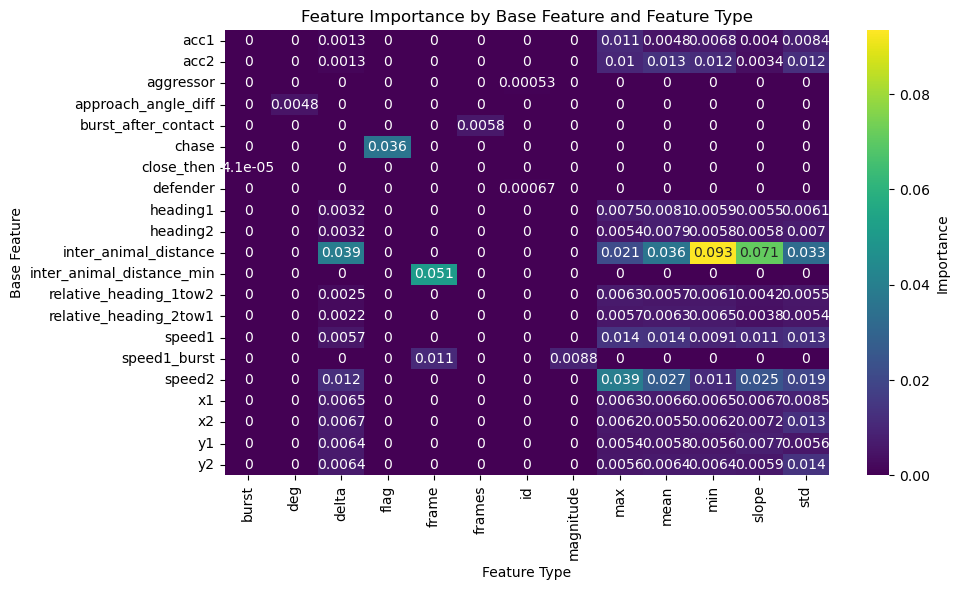

In [82]:
# 1. Get feature names used for training (before pruning)
X_full = X_y_df.drop(columns=["label", "frame"])  # Make sure this matches your model training
feature_names = X_full.columns.tolist()

# 2. Get feature importances from the trained classifier
importances = clf.feature_importances_

# 3. Confirm they match
assert len(feature_names) == len(importances), "Mismatch between features and importances!"

# 4. Create the DataFrame
importances_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Split base feature and type
importances_df["base_feature"] = importances_df["feature"].apply(lambda x: "_".join(x.split("_")[:-1]))
importances_df["feature_type"] = importances_df["feature"].apply(lambda x: x.split("_")[-1])

# Create a pivot table: rows = base features, columns = feature types
importance_matrix = importances_df.pivot_table(
    index="base_feature",
    columns="feature_type",
    values="importance",
    aggfunc="mean"  # safe since there's one row per feature
).fillna(0)

plt.figure(figsize=(10, 6))
sns.heatmap(importance_matrix, annot=True, cmap="viridis", cbar_kws={"label": "Importance"})
plt.title("Feature Importance by Base Feature and Feature Type")
plt.xlabel("Feature Type")
plt.ylabel("Base Feature")
plt.tight_layout()
plt.show()



In [83]:
# feature pruning
df_windowed = pd.read_csv("/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_pattern_vs_nopattern/analysis/rf_temporal_windowed_features_1_rot.csv")

# Separate X and y
X_all = df_windowed.drop(columns=["label", "frame"])
y = df_windowed["label"]

# Train a temporary model to get feature importances
clf_temp = RandomForestClassifier(class_weight="balanced", random_state=42)
clf_temp.fit(X_all, y)
importances_df = pd.DataFrame({
    "feature": X_all.columns,
    "importance": clf_temp.feature_importances_
})
useful_features = importances_df[importances_df["importance"] > 0.005]["feature"].tolist()

# Filter data to useful features
X = X_all[useful_features]

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train final model on pruned feature set
clf = RandomForestClassifier(class_weight="balanced", random_state=42)
clf.fit(X_train, y_train)

# Raw predictions
y_pred = clf.predict(X_test)
print("Raw predictions:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Thresholded predictions using probabilities
y_probs = clf.predict_proba(X_test)[:, 1]
threshold = 0.4
y_pred_adjusted = (y_probs >= threshold).astype(int)

print(f"\nThreshold-adjusted predictions (threshold={threshold}):")
print(confusion_matrix(y_test, y_pred_adjusted))
print(classification_report(y_test, y_pred_adjusted))

new_model_path = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/ML_model/clf_v1_t1_pruned.pkl"

joblib.dump((clf, X_train.columns.tolist()), new_model_path)

print(f"Pruned model saved to: {new_model_path}")

# # Optional: ROC-AUC and F1
# print("F1 (adjusted):", f1_score(y_test, y_pred_adjusted))
# print("ROC-AUC:", roc_auc_score(y_test, y_probs))

Raw predictions:
[[3403   43]
 [  66  800]]
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98      3446
         1.0       0.95      0.92      0.94       866

    accuracy                           0.97      4312
   macro avg       0.96      0.96      0.96      4312
weighted avg       0.97      0.97      0.97      4312


Threshold-adjusted predictions (threshold=0.4):
[[3380   66]
 [  45  821]]
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98      3446
         1.0       0.93      0.95      0.94       866

    accuracy                           0.97      4312
   macro avg       0.96      0.96      0.96      4312
weighted avg       0.97      0.97      0.97      4312

Pruned model saved to: /Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/ML_model/clf_v1_t1_pruned.pkl


Predict lables

In [96]:
# Load model and expected features
clf, expected_features = joblib.load("/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/ML_model/clf_v1_t1_pruned.pkl")

# Load new data
df_new = pd.read_csv("/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_TL_20250704/analysis/rf_temporal_windowed_features_1.csv")
X_new = df_new[expected_features]

# Feature sanity check
assert set(X_new.columns) == set(expected_features), "Feature mismatch!"

# Predict with threshold
probs = clf.predict_proba(X_new)[:, 1]
preds = (probs >= 0.4).astype(int)

# Save predictions
df_new["predicted_label"] = preds
df_new.to_csv(
    "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_TL_20250704/analysis/predicted_temporal_features_1.csv",
    index=False
)


In [97]:
print("CSV columns:", df_new.columns.tolist())
print("Expected features:", expected_features)


CSV columns: ['inter_animal_distance_slope', 'inter_animal_distance_delta', 'inter_animal_distance_mean', 'inter_animal_distance_std', 'inter_animal_distance_max', 'inter_animal_distance_min', 'speed1_slope', 'speed1_delta', 'speed1_mean', 'speed1_std', 'speed1_max', 'speed1_min', 'speed2_slope', 'speed2_delta', 'speed2_mean', 'speed2_std', 'speed2_max', 'speed2_min', 'acc1_slope', 'acc1_delta', 'acc1_mean', 'acc1_std', 'acc1_max', 'acc1_min', 'acc2_slope', 'acc2_delta', 'acc2_mean', 'acc2_std', 'acc2_max', 'acc2_min', 'heading1_slope', 'heading1_delta', 'heading1_mean', 'heading1_std', 'heading1_max', 'heading1_min', 'heading2_slope', 'heading2_delta', 'heading2_mean', 'heading2_std', 'heading2_max', 'heading2_min', 'relative_heading_1tow2_slope', 'relative_heading_1tow2_delta', 'relative_heading_1tow2_mean', 'relative_heading_1tow2_std', 'relative_heading_1tow2_max', 'relative_heading_1tow2_min', 'relative_heading_2tow1_slope', 'relative_heading_2tow1_delta', 'relative_heading_2tow1_

Prediction check

=== Classification Report ===
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     17227
         1.0       0.96      0.99      0.97      4332

    accuracy                           0.99     21559
   macro avg       0.98      0.99      0.98     21559
weighted avg       0.99      0.99      0.99     21559



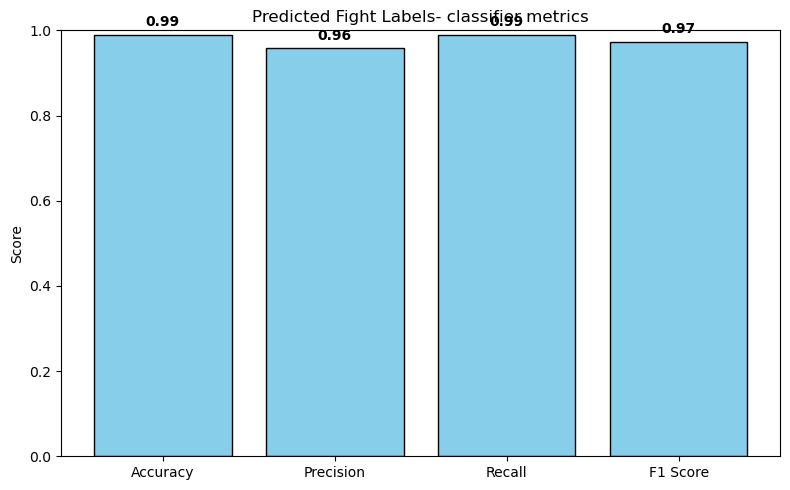

In [89]:
# --- File paths ---
manual_csv = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_pattern_vs_nopattern/analysis/rf_temporal_windowed_features_1_rot.csv"     
predicted_csv = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_pattern_vs_nopattern/analysis/predicted_temporal_features_1_rot.csv"   

# --- Load and align ---
df_manual = pd.read_csv(manual_csv)
df_pred = pd.read_csv(predicted_csv)

merged = pd.merge(
    df_manual[["frame", "label"]],
    df_pred[["frame", "predicted_label"]],
    on="frame",
    how="inner"
)

# --- Metrics ---
y_true = merged["label"]
y_pred = merged["predicted_label"]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("=== Classification Report ===")
print(classification_report(y_true, y_pred))

# --- Bar Plot ---
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

labels = list(metrics.keys())
values = list(metrics.values())

plt.figure(figsize=(8, 5))
plt.bar(labels, values, color="skyblue", edgecolor="black")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Predicted Fight Labels- classifier metrics")

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight='bold')

plt.tight_layout()
plt.savefig("/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_pattern_vs_nopattern/analysis/fight_label_comparison_barplot_1_rot.png")
plt.show()

Retrain

In [35]:
feature_names = list(X.columns)
print("TRAINING FEATURES:", feature_names)

df_train = pd.read_csv("/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_150mm_30dpf_20250516/Analysis/features_with_labels_rot_manual.csv")
label_col = "fight_label"
X_train = df_train.drop(columns=["frame", label_col])
print(df_train.columns.tolist())

y_train = df_train[label_col]
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
joblib.dump((model, X_train.columns.tolist()), "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/ML_model/clf_v1.pkl")

TRAINING FEATURES: ['inter_animal_distance_slope', 'inter_animal_distance_delta', 'inter_animal_distance_mean', 'inter_animal_distance_std', 'inter_animal_distance_max', 'inter_animal_distance_min', 'speed1_slope', 'speed1_delta', 'speed1_mean', 'speed1_std', 'speed1_max', 'speed1_min', 'speed2_slope', 'speed2_delta', 'speed2_mean', 'speed2_std', 'speed2_max', 'speed2_min', 'acc1_slope', 'acc1_delta', 'acc1_mean', 'acc1_std', 'acc1_max', 'acc1_min', 'acc2_slope', 'acc2_delta', 'acc2_mean', 'acc2_std', 'acc2_max', 'acc2_min', 'heading1_slope', 'heading1_delta', 'heading1_mean', 'heading1_std', 'heading1_max', 'heading1_min', 'heading2_slope', 'heading2_delta', 'heading2_mean', 'heading2_std', 'heading2_max', 'heading2_min', 'relative_heading_1tow2_slope', 'relative_heading_1tow2_delta', 'relative_heading_1tow2_mean', 'relative_heading_1tow2_std', 'relative_heading_1tow2_max', 'relative_heading_1tow2_min', 'relative_heading_2tow1_slope', 'relative_heading_2tow1_delta', 'relative_heading_

['/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/ML_model/clf_v1.pkl']

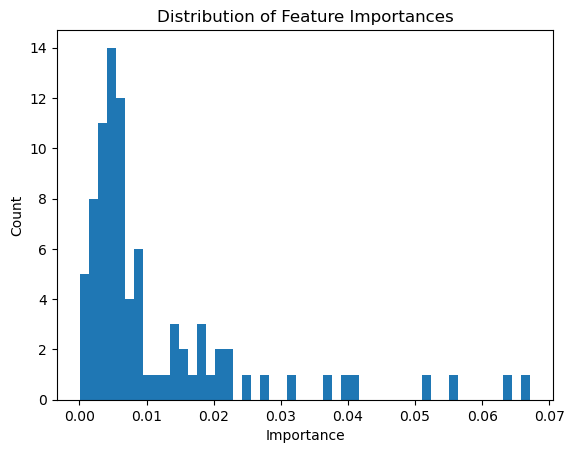

                            feature  importance
5         inter_animal_distance_min    0.071327
2        inter_animal_distance_mean    0.070977
16                       speed2_max    0.053740
4         inter_animal_distance_max    0.045677
0       inter_animal_distance_slope    0.041168
69                           x2_std    0.037622
1       inter_animal_distance_delta    0.033140
14                      speed2_mean    0.031506
75                           y2_std    0.029307
17                       speed2_min    0.024095
15                       speed2_std    0.023968
70                           x2_max    0.021822
78                       chase_flag    0.020993
10                       speed1_max    0.019907
81  inter_animal_distance_min_frame    0.019498
3         inter_animal_distance_std    0.018277
68                          x2_mean    0.017718
9                        speed1_std    0.017197
12                     speed2_slope    0.016206
27                         acc2_std    0

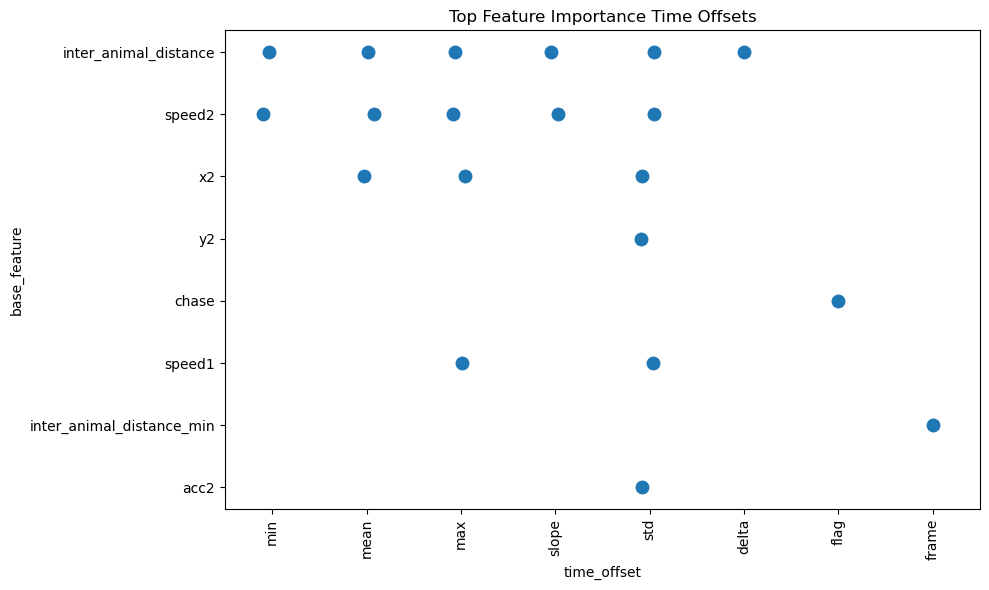

In [41]:
plt.hist(importances, bins=50)
plt.title("Distribution of Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Count")
plt.show()

top_n = 20  # Adjust as needed
top_features = importances_df.sort_values(by="importance", ascending=False).head(top_n)
print(top_features)

top_features["base_feature"] = top_features["feature"].apply(lambda x: "_".join(x.split("_")[:-1]))
top_features["time_offset"] = top_features["feature"].apply(lambda x: x.split("_")[-1])

plt.figure(figsize=(10, 6))
sns.stripplot(data=top_features, y="base_feature", x="time_offset", size=10)
plt.title("Top Feature Importance Time Offsets")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Append centroid values to predicted labels csv

In [98]:
# Original files
predicted_features_csv = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_TL_20250704/analysis/predicted_temporal_features_1.csv"
tracking_csv = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_TL_20250704/idtracker/session_ABpatternvsABpattern_trimmed_cropped/trajectories/trajectories_csv/trajectories.csv"

# Output (safe copy with centroids)
features_with_centroids_csv = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_TL_20250704/analysis/rf_temporal_windowed_features_with_centroids_1.csv"

df_window = pd.read_csv(predicted_features_csv)
df_tracking = pd.read_csv(tracking_csv)

# Convert time to frame index (assuming 60 fps)
fps = 60
df_tracking["frame"] = (df_tracking["time"] * fps).round().astype(int)

# Keep only needed columns
df_tracking = df_tracking[["frame", "x1", "y1", "x2", "y2"]]

# Merge with a copy of df_window
df_annot = df_window.merge(df_tracking, on="frame", how="left")

# Save the new file for annotation
df_annot.to_csv(features_with_centroids_csv, index=False)
print(f"Saved annotated features with centroids to: {features_with_centroids_csv}")

Saved annotated features with centroids to: /Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_TL_20250704/analysis/rf_temporal_windowed_features_with_centroids_1.csv


Annotate video with labels

In [99]:
import cv2
import pandas as pd
import joblib
from collections import deque

# --- CONFIGURATION ---
model_path = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/ML_model/clf_v1_t1_pruned.pkl"
video_path = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_TL_20250704/analysis/ABpatternvsABpattern_trimmed_cropped.mp4"
features_csv = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_TL_20250704/analysis/rf_temporal_windowed_features_with_centroids_1.csv"
output_video_path = "/Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_TL_20250704/analysis/annotated_video_ml_1.mp4"
threshold = 0.5
trail_length = 30  # Number of past frames to keep

# --- Load model and data ---
clf, expected_features = joblib.load(model_path)
df = pd.read_csv(features_csv)
missing = set(expected_features) - set(df.columns)
if missing:
    raise ValueError(f"Missing expected features in CSV: {missing}")

X = df[expected_features]
df["predicted_label"] = (clf.predict_proba(X)[:, 1] >= threshold).astype(int)
frame_data = df.set_index("frame")
frames = df["frame"].astype(int)

# --- Open video ---
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

# --- Trajectory buffers ---
trail_ag = deque(maxlen=trail_length)
trail_df = deque(maxlen=trail_length)

frame_idx = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx in frame_data.index:
        row = frame_data.loc[frame_idx]

        # Draw basic centroids
        if pd.notnull(row["x1"]) and pd.notnull(row["y1"]):
            cv2.circle(frame, (int(row["x1"]), int(row["y1"])), 3, (0, 0, 255), -1)  # red
        if pd.notnull(row["x2"]) and pd.notnull(row["y2"]):
            cv2.circle(frame, (int(row["x2"]), int(row["y2"])), 3, (0, 255, 255), -1)  # yellow

        if row["predicted_label"] == 1:
            # Draw fight label
            cv2.putText(frame, "FIGHT", (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 0, 255), 6)

            required_cols = ["x1", "y1", "x2", "y2", "aggressor_id"]
            if all(pd.notnull(row[col]) for col in required_cols):
                try:
                    x1, y1 = int(row["x1"]), int(row["y1"])
                    x2, y2 = int(row["x2"]), int(row["y2"])
                    ag_id = int(row["aggressor_id"])

                    if ag_id == 1:
                        ag_pos = (x1, y1)
                        df_pos = (x2, y2)
                    elif ag_id == 2:
                        ag_pos = (x2, y2)
                        df_pos = (x1, y1)
                    else:
                        ag_pos = df_pos = None
                        print(f"Invalid aggressor_id at frame {frame_idx}: {ag_id}")

                    # Draw enhanced circles
                    if ag_pos:
                        cv2.circle(frame, ag_pos, 5, (255, 0, 0), -1)  # blue = aggressor
                        trail_ag.append(ag_pos)
                    if df_pos:
                        cv2.circle(frame, df_pos, 5, (0, 255, 0), -1)  # green = defender
                        trail_df.append(df_pos)

                    # Draw trails as dotted points (scatter)
                    for pos in trail_ag:
                        cv2.circle(frame, pos, 1, (255, 0, 0), -1)  

                    for pos in trail_df:
                        cv2.circle(frame, pos, 1, (0, 255, 0), -1)  


                except Exception as e:
                    print(f"Error drawing fight visuals at frame {frame_idx}: {e}")
            else:
                print(f"Missing centroid or ID at frame {frame_idx}")
        else:
            # No fight: reset trails
            trail_ag.clear()
            trail_df.clear()

    out.write(frame)
    frame_idx += 1

# --- Cleanup ---
cap.release()
out.release()
print(f"Annotated video saved to: {output_video_path}")


Missing centroid or ID at frame 20726
Missing centroid or ID at frame 20728
Annotated video saved to: /Volumes/jlarsch/default/D2c/Deeksha/Territory_assay/TA_200mm_30dpf_AB_TL_20250704/analysis/annotated_video_ml_1.mp4
